In [1]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt 
import seaborn as sns


In [16]:
wine_df = pd.read_csv('winequality-red.csv')

In [17]:
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:
wine_df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

#the quality of wine 3 to 8 
#if 3 4 5 = low
#if 6 7 8 = high

In [19]:
wine_df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [20]:
print(wine_df["quality"].value_counts())


quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


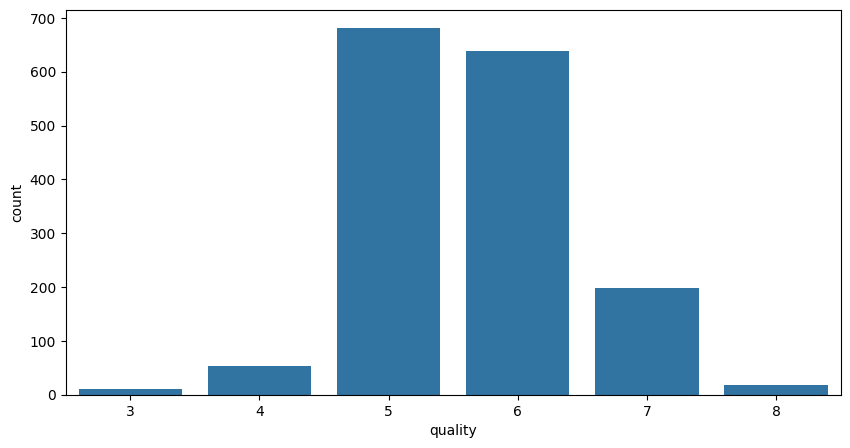

In [24]:
fig = plt.figure(figsize=(10, 5))
sns.countplot(x='quality',data=wine_df)
plt.show()

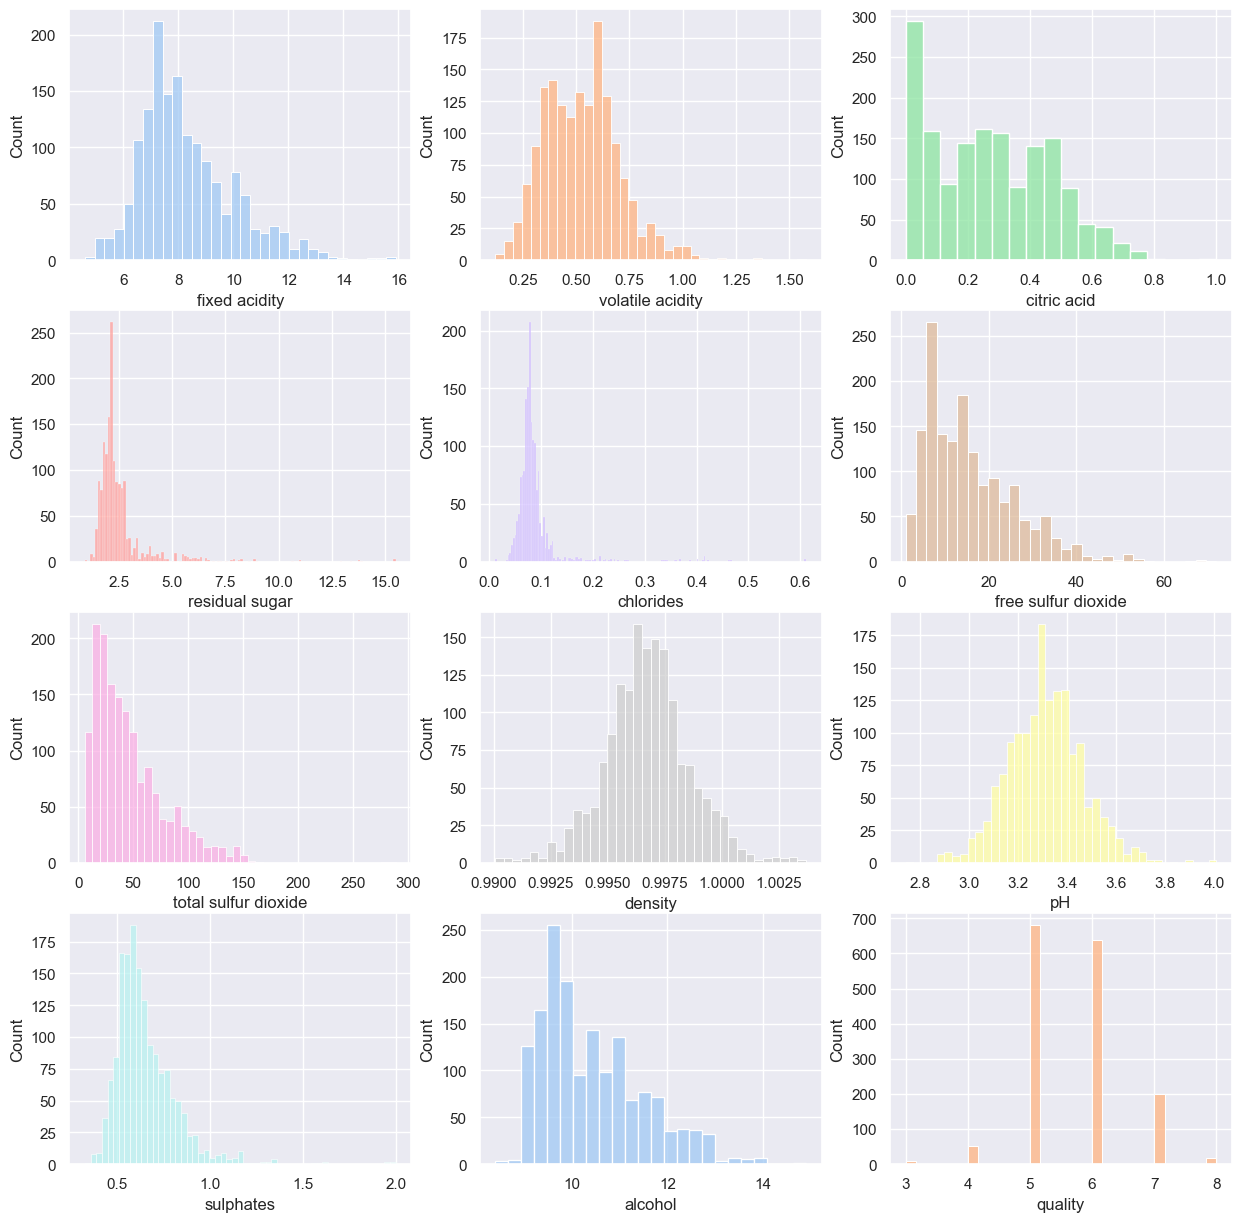

In [33]:
#visualization the distribution of all features

sns.set(style="darkgrid")
columns= list(wine_df.columns)
colors = sns.color_palette("pastel", len(columns))

fig, axes = plt.subplots(4,3,figsize = (15,15))
k=0

for i in range(4):
    for j in range(3):
        if k < len(columns):
            sns.histplot(wine_df[columns[k]],ax=axes[i][j],color=colors[k])
            k+=1

plt.show()

In [51]:
def log_transform(column):
    return numpy.log1p(column.c[0])
wine_df['residual_sugar'] = wine_df[['residual sugar']].apply(log_transform, axis=1)
wine_df['chlorides'] = wine_df[['chlorides']].apply(log_transform, axis=1)
wine_df['free_sulfur_dioxide'] = wine_df[['free sulfur dioxide']].apply(log_transform, axis=1)
wine_df['total_sulfur_dioxide'] = wine_df[['total sulfur dioxide']].apply(log_transform, axis=1)
wine_df['sulphates'] = wine_df[['sulphates']].apply(log_transform, axis=1)

AttributeError: 'Series' object has no attribute 'c'

In [50]:
wine_df.corr().sort_values(by='quality',asceding= False)

TypeError: DataFrame.sort_values() got an unexpected keyword argument 'asceding'

In [43]:
X = wine_df.drop('quality',axis = 1)
y = wine_df['quality']

In [47]:
#classify function
from sklearn.model_selection import train_test_split, cross_val_score

def classify(model,x,y):
    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
    model.fit(x_train,y_train)

    return model.score(x_test,y_test)*100

In [75]:
#logistic regression
from sklearn.linear_model import LogisticRegression

lm_rl = LogisticRegression()

accuracy_lr = classify(lm_rl, X, y)
print("LogisticRegression accuracy: {:<0.2f}".format(accuracy_lr))

LogisticRegression accuracy: 54.37


C:\Users\praha\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [78]:
#decision treee classifier
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
accuracy_dtc = classify(model, X, y)
print("DecisionTreeClassifier accuracy: {:<0.2f}". format(accuracy_dtc))

DecisionTreeClassifier accuracy: 55.94


In [80]:
#random forest classifier
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
accuracy_lr = classify(model, X, y)
print("RandomForestClassifier accuracy: {:<0.2f}". format(accuracy_lr))

RandomForestClassifier accuracy: 65.62


C:\Users\praha\AppData\Local\Temp\ipykernel_15416\660026909.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='pastel')


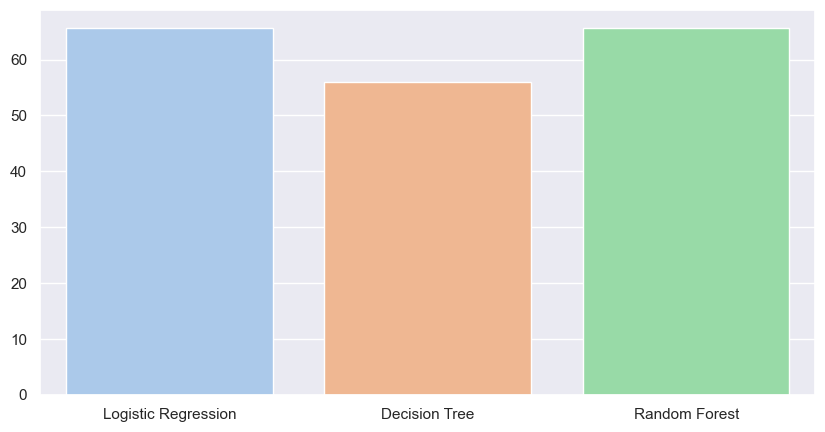

In [82]:
#ploting the accuracy of all models
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [accuracy_lr, accuracy_dtc, accuracy_lr]
plt.figure(figsize=(10,5))
sns.barplot(x=models, y=accuracies, palette='pastel') 
plt.show()  

In [1]:
#predict the quality of wine
#inserting the new data

model=RandomForestClassifier()
model.fit(X,y)

sample_data=(7.4,0.7,1.9,0.076,11,34,0.09978,3.51,0.56,9.4)
sample_data=np.array(sample_data).reshape(1,-1)

NameError: name 'RandomForestClassifier' is not defined

In [89]:
import pickle
with open('wine_quality_model.pkl', 'wb') as f:
    pickle.dump(model, f)
    print("Model saved to wine_quality_model.pkl successfully.")

Model saved to wine_quality_model.pkl successfully.
